In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler ,OneHotEncoder

In [112]:
df = pd.read_csv("/content/Internship_Selection_Dataset.csv")

In [113]:
df.head()

,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,college_tier,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,Tier 2,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,Tier 2,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,Tier 2,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,Tier 2,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,Tier 3,4,7,3,8,7,8,6,5,Yes,1


In [114]:
df['selected'].value_counts()

,count
selected,
1,7374
0,2626


In [115]:
df.isnull().sum()

,0
student_id,0
CGPA,0
skills_score,0
projects_count,0
internships_done,0
communication_score,0
aptitude_score,0
coding_test_score,0
resume_score,0
extracurricular,0


In [116]:
df.duplicated().sum()

np.int64(0)

In [117]:
df.shape

(10000, 21)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               10000 non-null  int64  
 1   CGPA                     10000 non-null  float64
 2   skills_score             10000 non-null  int64  
 3   projects_count           10000 non-null  int64  
 4   internships_done         10000 non-null  int64  
 5   communication_score      10000 non-null  int64  
 6   aptitude_score           10000 non-null  int64  
 7   coding_test_score        10000 non-null  int64  
 8   resume_score             10000 non-null  int64  
 9   extracurricular          10000 non-null  object 
 10  college_tier             10000 non-null  object 
 11  hackathons_participated  10000 non-null  int64  
 12  certifications_count     10000 non-null  int64  
 13  linkedin_activity_score  10000 non-null  int64  
 14  github_score           

In [119]:
df.drop('student_id',axis=1,inplace=True)

In [120]:
print(df['extracurricular'].unique())
print(df['college_tier'].unique())
print(df['placement_training'].unique())

['Yes' 'No']
['Tier 2' 'Tier 3' 'Tier 1']
['Yes' 'No']


In [121]:
df['extracurricular']=df['extracurricular'].map({'Yes':1, 'No':0 })
df['placement_training']=df['placement_training'].map({'Yes':1, 'No':0})

In [122]:
OHE = OneHotEncoder(drop='first',sparse_output=False)
encoded = OHE.fit_transform(df[['college_tier']])
encoded_df = pd.DataFrame(
    encoded,
    columns=OHE.get_feature_names_out(['college_tier'])
)
df = pd.concat(
    [df.drop('college_tier', axis=1), encoded_df],
    axis=1
)

In [123]:
df['extracurricular']

,extracurricular
0,1
1,1
2,1
3,0
4,1
...,...
9995,0
9996,1
9997,1
9998,0


In [124]:
df['placement_training']

,placement_training
0,1
1,1
2,1
3,1
4,1
...,...
9995,0
9996,1
9997,0
9998,0


In [125]:
df

,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected,college_tier_Tier 2,college_tier_Tier 3
0,6.87,7,0,0,4,3,2,7,1,0,7,5,9,3,1,4,4,1,1,1.0,0.0
1,9.75,4,4,2,3,3,6,1,1,3,2,8,8,3,9,8,5,1,1,1.0,0.0
2,8.66,2,1,1,2,1,4,6,1,4,1,5,2,2,1,3,2,1,1,1.0,0.0
3,7.99,5,4,2,8,8,10,8,0,1,5,5,9,2,7,10,1,1,1,1.0,0.0
4,5.78,3,2,2,4,9,1,7,1,4,7,3,8,7,8,6,5,1,1,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9.29,8,3,1,10,2,4,6,0,4,5,10,2,6,5,3,4,0,0,1.0,0.0
9996,9.49,4,2,1,7,1,3,5,1,2,8,6,10,1,5,1,1,1,0,0.0,0.0
9997,9.73,8,0,0,1,4,4,9,1,3,6,4,5,9,10,2,3,0,1,1.0,0.0
9998,6.99,5,1,1,3,6,9,5,0,2,2,10,2,4,8,1,4,0,1,1.0,0.0


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CGPA                     10000 non-null  float64
 1   skills_score             10000 non-null  int64  
 2   projects_count           10000 non-null  int64  
 3   internships_done         10000 non-null  int64  
 4   communication_score      10000 non-null  int64  
 5   aptitude_score           10000 non-null  int64  
 6   coding_test_score        10000 non-null  int64  
 7   resume_score             10000 non-null  int64  
 8   extracurricular          10000 non-null  int64  
 9   hackathons_participated  10000 non-null  int64  
 10  certifications_count     10000 non-null  int64  
 11  linkedin_activity_score  10000 non-null  int64  
 12  github_score             10000 non-null  int64  
 13  soft_skills_score        10000 non-null  int64  
 14  interview_score        

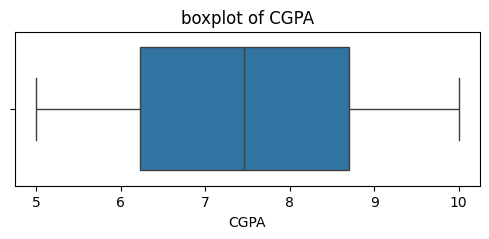

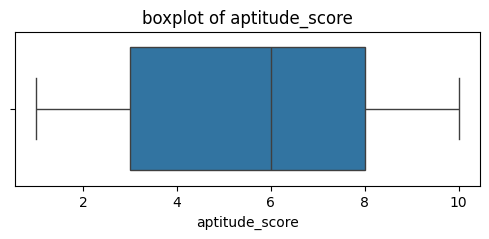

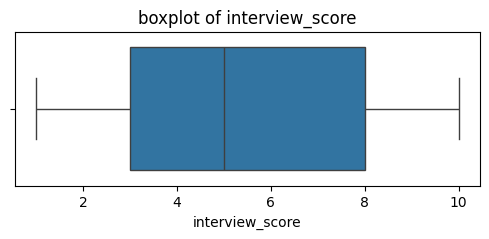

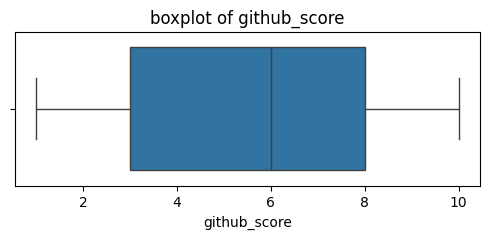

In [127]:
important_cols = [
    'CGPA',
    'aptitude_score',
    'interview_score',
    'github_score'
]

for col in important_cols:
  plt.figure(figsize=(6,2))
  sns.boxplot(x=df[col])
  plt.title(f'boxplot of {col}')
  plt.show()

there is no need to change anything as there is no outliers in the data

In [128]:
df.corr()

,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected,college_tier_Tier 2,college_tier_Tier 3
CGPA,1.000000,-0.006062,0.020954,-0.001184,-0.016028,0.006523,0.005060,0.015237,0.014067,0.023094,-0.004572,-0.004020,0.001991,-0.012491,-0.009563,-0.016030,-0.007938,0.004757,0.027016,0.006015,-0.007792
skills_score,-0.006062,1.000000,-0.015557,0.004458,0.008549,-0.000724,0.000629,-0.008929,-0.002919,-0.002213,-0.002181,-0.006207,-0.003023,-0.001780,-0.010844,-0.017833,-0.002696,-0.001560,0.058453,0.009491,0.000591
projects_count,0.020954,-0.015557,1.000000,-0.006111,0.009002,0.001000,-0.024157,-0.005888,0.005903,-0.004562,0.000183,0.014841,0.005938,-0.015759,-0.014372,-0.009751,-0.006039,0.002700,0.035092,0.003007,0.030245
internships_done,-0.001184,0.004458,-0.006111,1.000000,-0.002794,-0.014372,0.001159,-0.001043,0.007596,-0.004166,0.004968,-0.013449,0.001201,-0.017324,-0.019112,0.001889,-0.002177,-0.005951,0.029197,0.000558,0.001113
communication_score,-0.016028,0.008549,0.009002,-0.002794,1.000000,-0.000277,0.015921,0.027236,0.012492,-0.000871,-0.002933,0.003010,0.012599,-0.001194,-0.013720,0.005052,-0.014419,0.002726,0.044100,-0.017768,0.020606
aptitude_score,0.006523,-0.000724,0.001000,-0.014372,-0.000277,1.000000,0.022558,0.014191,0.012371,-0.004771,0.020674,0.020732,-0.007079,-0.006655,0.009420,-0.006152,-0.004821,-0.006703,0.024051,0.013035,-0.007629
coding_test_score,0.005060,0.000629,-0.024157,0.001159,0.015921,0.022558,1.000000,-0.003392,0.007372,0.010187,-0.003557,-0.017128,-0.011852,0.014098,0.012386,0.008795,0.019938,0.000296,0.035067,0.001896,-0.005327
resume_score,0.015237,-0.008929,-0.005888,-0.001043,0.027236,0.014191,-0.003392,1.000000,0.000533,-0.002258,0.007270,-0.004962,-0.001726,-0.015950,-0.004418,0.006551,-0.015932,0.013697,0.036477,-0.001318,0.012121
extracurricular,0.014067,-0.002919,0.005903,0.007596,0.012492,0.012371,0.007372,0.000533,1.000000,-0.012871,0.007939,-0.003008,-0.002867,-0.014268,-0.012993,-0.008658,0.016221,0.014201,0.027474,-0.003989,0.003960
hackathons_participated,0.023094,-0.002213,-0.004562,-0.004166,-0.000871,-0.004771,0.010187,-0.002258,-0.012871,1.000000,-0.022012,0.015869,-0.003275,-0.013020,-0.003518,0.001487,-0.004039,0.007371,0.008805,0.000900,-0.005028


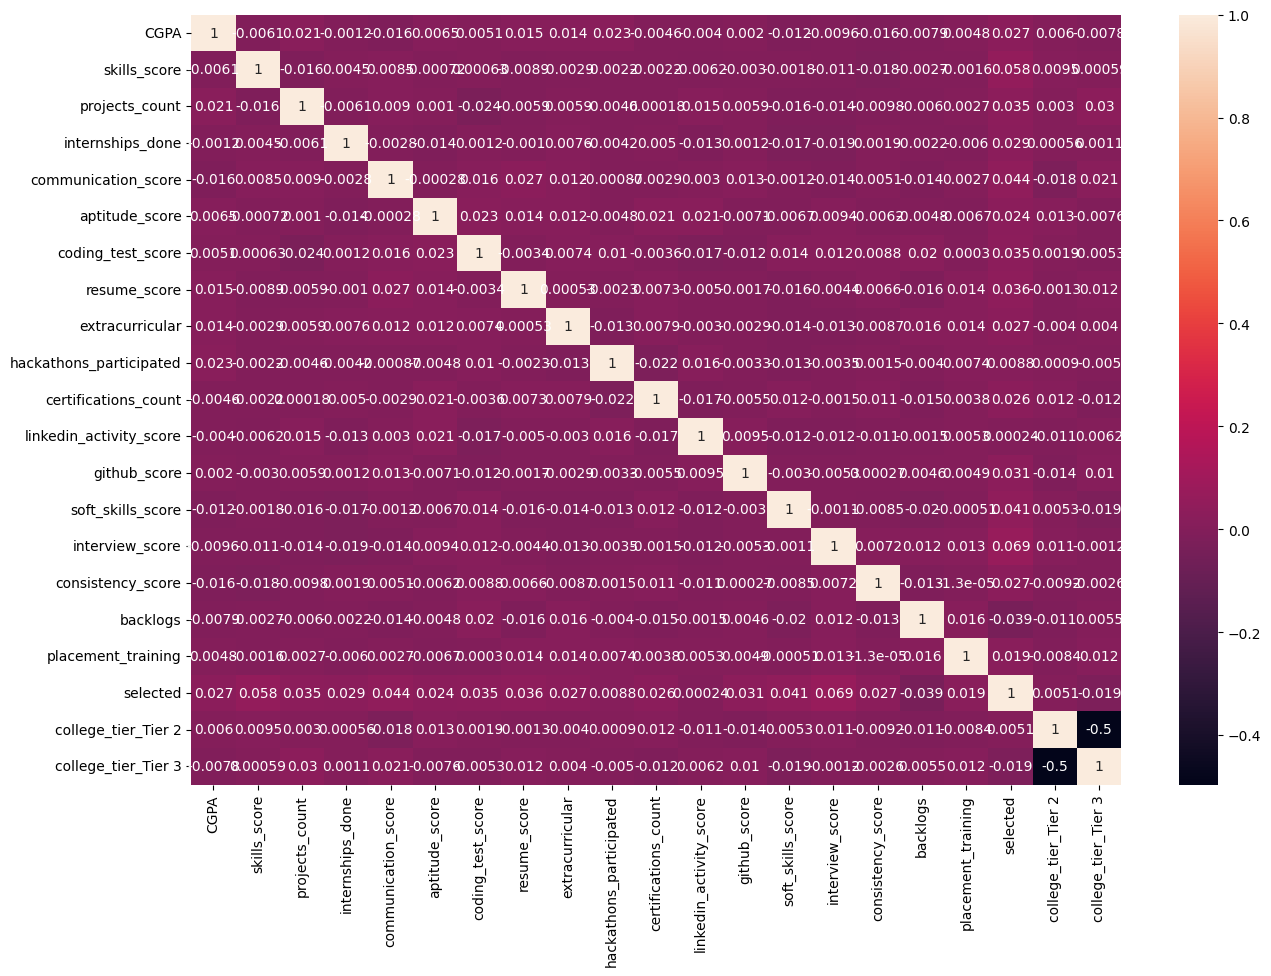

In [129]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [130]:
df.corr()['selected'].sort_values(ascending = False)

,selected
selected,1.000000
interview_score,0.069152
skills_score,0.058453
communication_score,0.044100
soft_skills_score,0.041482
resume_score,0.036477
projects_count,0.035092
coding_test_score,0.035067
github_score,0.031460
internships_done,0.029197


In [131]:
df.skew(numeric_only=True)

,0
CGPA,0.024830
skills_score,0.010102
projects_count,-0.047869
internships_done,-0.004155
communication_score,-0.021391
aptitude_score,-0.017825
coding_test_score,0.026063
resume_score,-0.031931
extracurricular,-0.418959
hackathons_participated,-0.019437


In [132]:
X = df.drop('selected', axis=1)
y = df['selected']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [138]:
num_cols = X_train.columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])